# 🏥 Drug Side Effect Detection — RoBERTa Class Weight

**Dataset**: ADE-Corpus-V2 (Gurulingappa et al., 2012)  
**Model**: RoBERTa-base  
**Strategi**: Class Weight — CrossEntropyLoss dengan bobot kelas untuk menangani imbalanced data

---

## 📦 CELL 1 — Instalasi Library

In [1]:
# Install semua dependensi
!pip install -q transformers datasets scikit-learn torch torchvision
!pip install -q mlflow seaborn matplotlib pandas numpy
!pip install -q accelerate -U

print('✅ Semua library berhasil diinstall!')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 46.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 41.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 39.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 887.6/887.6 kB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207

## 📚 CELL 2 — Import Library

In [2]:
# ── Standard Library ──
import os
import json
import time
import hashlib
import warnings
import datetime
warnings.filterwarnings('ignore')

# ── Data ──
import numpy as np
import pandas as pd
from datasets import load_dataset

# ── Visualisasi ──
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# ── Scikit-learn ──
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score, precision_score, recall_score,
    roc_auc_score, roc_curve
)

# ── PyTorch ──
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# ── HuggingFace Transformers ──
from transformers import (
    RobertaTokenizer,
    RobertaForSequenceClassification,
    get_linear_schedule_with_warmup
)

# ── MLflow ──
import mlflow
import mlflow.pytorch

# ── Device setup ──
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'🖥️  Device: {device}')
if torch.cuda.is_available():
    print(f'   GPU: {torch.cuda.get_device_name(0)}')
    print(f'   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

🖥️  Device: cuda
   GPU: Tesla T4
   VRAM: 15.6 GB


## 📥 CELL 3 — Load Dataset & Dataset Tracking

In [3]:
# =============================================
# Load Dataset dari HuggingFace
# =============================================
print('📥 Memuat ADE-Corpus-V2 dari HuggingFace...')
raw = load_dataset('ade_corpus_v2', 'Ade_corpus_v2_classification')

# Gabungkan semua split
all_data = []
for split in raw:
    for item in raw[split]:
        all_data.append({'text': item['text'], 'label': item['label']})

df = pd.DataFrame(all_data).drop_duplicates(subset='text').reset_index(drop=True)

print(f'✅ Dataset berhasil dimuat: {len(df):,} sampel unik')

# =============================================
# DATASET TRACKING — Metadata & Versioning
# =============================================
print('\n' + '='*55)
print('📋 DATASET TRACKING & VERSIONING')
print('='*55)

# Buat hash dataset untuk versioning
dataset_str = df['text'].str.cat(sep='|')
dataset_hash = hashlib.md5(dataset_str.encode()).hexdigest()[:12]

# Metadata dataset
dataset_metadata = {
    'dataset_name'    : 'ADE-Corpus-V2 (Classification)',
    'source'          : 'Gurulingappa et al., 2012 — HuggingFace Hub',
    'version_hash'    : dataset_hash,
    'loaded_at'       : datetime.datetime.now().isoformat(),
    'total_samples'   : len(df),
    'num_features'    : len(df.columns),
    'num_classes'     : df['label'].nunique(),
    'class_names'     : {0: 'Non-ADE', 1: 'ADE'},
    'class_counts'    : df['label'].value_counts().to_dict(),
    'class_ratio'     : round(df['label'].value_counts(normalize=True).to_dict()[0], 4),
    'has_nulls'       : df.isnull().sum().sum(),
    'has_duplicates'  : 0,  # sudah di-drop
}

for k, v in dataset_metadata.items():
    print(f'  {k:<22}: {v}')

# Simpan metadata ke JSON
with open('dataset_metadata.json', 'w') as f:
    json.dump(dataset_metadata, f, indent=2, default=str)
print('\n💾 Metadata disimpan ke: dataset_metadata.json')

📥 Memuat ADE-Corpus-V2 dari HuggingFace...


README.md: 0.00B [00:00, ?B/s]

Ade_corpus_v2_classification/train-00000(…):   0%|          | 0.00/1.71M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/23516 [00:00<?, ? examples/s]

✅ Dataset berhasil dimuat: 20,896 sampel unik

📋 DATASET TRACKING & VERSIONING
  dataset_name          : ADE-Corpus-V2 (Classification)
  source                : Gurulingappa et al., 2012 — HuggingFace Hub
  version_hash          : 10469a693dd4
  loaded_at             : 2026-05-14T13:10:12.508392
  total_samples         : 20896
  num_features          : 2
  num_classes           : 2
  class_names           : {0: 'Non-ADE', 1: 'ADE'}
  class_counts          : {0: 16625, 1: 4271}
  class_ratio           : 0.7956
  has_nulls             : 0
  has_duplicates        : 0

💾 Metadata disimpan ke: dataset_metadata.json


## 📊 CELL 4 — EDA (Exploratory Data Analysis)

📊 DISTRIBUSI LABEL
  Label 0 (Non-ADE (0)): 16,625   79.6%  ███████████████████████████████████████
  Label 1 (ADE (1)):  4,271   20.4%  ██████████
  Rasio imbalance: 1 : 3.89


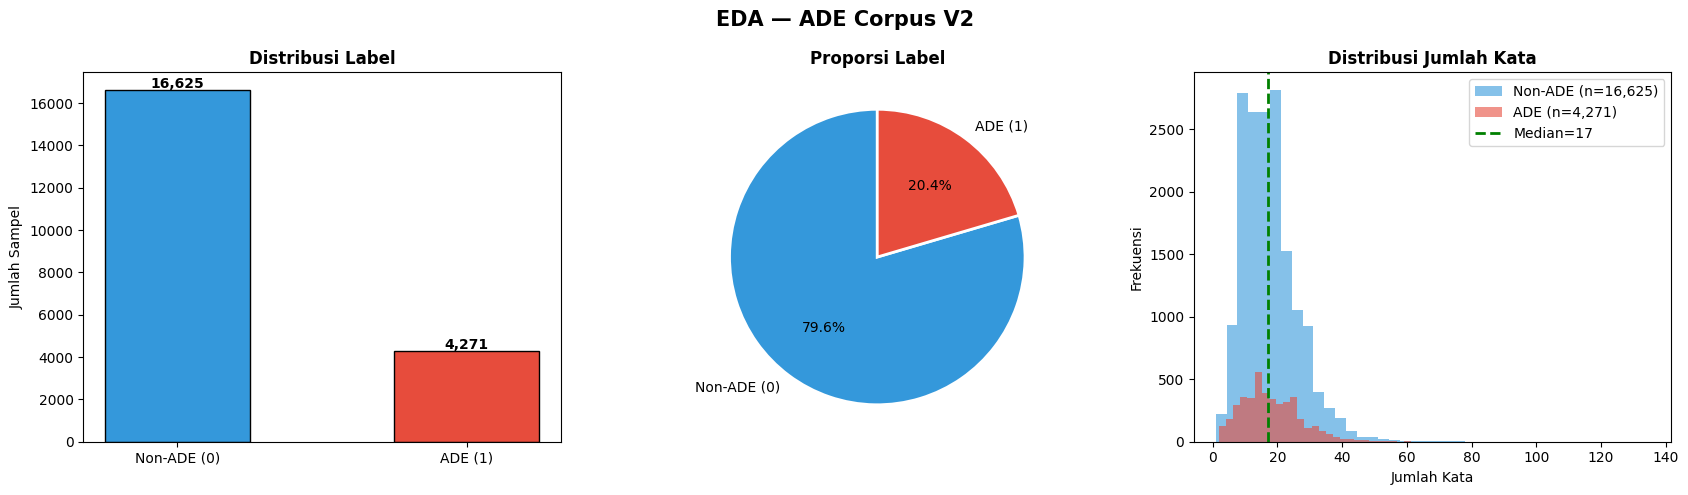


📏 STATISTIK PANJANG TEKS PER LABEL:
      text_length                                               word_count                                         
            count   mean   std   min   25%    50%    75%    max      count  mean  std  min   25%   50%   75%    max
label                                                                                                              
0         16625.0  125.1  57.7   7.0  84.0  116.0  156.0  742.0    16625.0  17.8  8.5  1.0  12.0  16.0  22.0  135.0
1          4271.0  132.2  60.7  17.0  87.0  124.0  168.0  568.0     4271.0  18.0  9.1  2.0  11.0  17.0  23.0   90.0


In [4]:
# ── Fitur panjang teks ──
df['text_length'] = df['text'].apply(len)
df['word_count']  = df['text'].apply(lambda x: len(x.split()))

label_counts = df['label'].value_counts()
label_names  = {0: 'Non-ADE (0)', 1: 'ADE (1)'}

print('='*55)
print('📊 DISTRIBUSI LABEL')
print('='*55)
for lbl, cnt in label_counts.items():
    pct = cnt / len(df) * 100
    bar = '█' * int(pct / 2)
    print(f'  Label {lbl} ({label_names[lbl]}): {cnt:>6,}  {pct:5.1f}%  {bar}')
print(f'  Rasio imbalance: 1 : {label_counts[0]/label_counts[1]:.2f}')

# ── Plot ──
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('EDA — ADE Corpus V2', fontsize=15, fontweight='bold')

# Bar chart
colors = ['#3498db', '#e74c3c']
axes[0].bar(label_names.values(), label_counts.values, color=colors, edgecolor='black', width=0.5)
axes[0].set_title('Distribusi Label', fontweight='bold')
axes[0].set_ylabel('Jumlah Sampel')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(label_counts.values, labels=label_names.values(),
            autopct='%1.1f%%', colors=colors, startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Proporsi Label', fontweight='bold')

# Histogram word count
for lbl, color, name in [(0, '#3498db', 'Non-ADE'), (1, '#e74c3c', 'ADE')]:
    subset = df[df['label'] == lbl]['word_count']
    axes[2].hist(subset, bins=40, alpha=0.6, color=color, label=f'{name} (n={len(subset):,})')
axes[2].axvline(df['word_count'].median(), color='green', linestyle='--', lw=2, label=f'Median={df["word_count"].median():.0f}')
axes[2].set_title('Distribusi Jumlah Kata', fontweight='bold')
axes[2].set_xlabel('Jumlah Kata')
axes[2].set_ylabel('Frekuensi')
axes[2].legend()

plt.tight_layout()
plt.savefig('eda_plot.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📏 STATISTIK PANJANG TEKS PER LABEL:')
print(df.groupby('label')[['text_length', 'word_count']].describe().round(1).to_string())

## ✂️ CELL 5 — Data Splitting (Stratified)

In [5]:
texts  = df['text'].tolist()
labels = df['label'].tolist()

# Split 70 / 15 / 15 dengan stratifikasi
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    texts, labels, test_size=0.30, random_state=42, stratify=labels
)
val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels, test_size=0.50, random_state=42, stratify=temp_labels
)

print('✅ Dataset berhasil dibagi:')
print(f'  🔵 Train      : {len(train_texts):>6,} sampel ({len(train_texts)/len(texts)*100:.1f}%)')
print(f'  🟡 Validation : {len(val_texts):>6,} sampel ({len(val_texts)/len(texts)*100:.1f}%)')
print(f'  🔴 Test       : {len(test_texts):>6,} sampel ({len(test_texts)/len(texts)*100:.1f}%)')

# Verifikasi stratifikasi
print('\n📊 Verifikasi distribusi label per split:')
for name, lbls in [('Train', train_labels), ('Val', val_labels), ('Test', test_labels)]:
    arr = np.array(lbls)
    pct0 = (arr == 0).mean() * 100
    pct1 = (arr == 1).mean() * 100
    print(f'  {name:<6}: Non-ADE={pct0:.1f}%  ADE={pct1:.1f}%  ✅')

# Dataset tracking — split info
split_info = {
    'train_size': len(train_texts),
    'val_size'  : len(val_texts),
    'test_size' : len(test_texts),
    'strategy'  : 'stratified 70/15/15',
    'random_state': 42,
}
with open('split_info.json', 'w') as f:
    json.dump(split_info, f, indent=2)
print('\n💾 Split info disimpan ke: split_info.json')

✅ Dataset berhasil dibagi:
  🔵 Train      : 14,627 sampel (70.0%)
  🟡 Validation :  3,134 sampel (15.0%)
  🔴 Test       :  3,135 sampel (15.0%)

📊 Verifikasi distribusi label per split:
  Train : Non-ADE=79.6%  ADE=20.4%  ✅
  Val   : Non-ADE=79.6%  ADE=20.4%  ✅
  Test  : Non-ADE=79.6%  ADE=20.4%  ✅

💾 Split info disimpan ke: split_info.json


## 🔤 CELL 6 — Tokenisasi & PyTorch Dataset

In [6]:
MODEL_NAME = 'roberta-base'
MAX_LENGTH = 128

print(f'📥 Memuat tokenizer: {MODEL_NAME}...')
tokenizer = RobertaTokenizer.from_pretrained(MODEL_NAME)
print(f'✅ Tokenizer berhasil dimuat!')

# ── Custom Dataset ──
class ADEDataset(Dataset):
    """
    Custom PyTorch Dataset untuk ADE Classification.
    Menerima list teks dan label, melakukan tokenisasi batch.
    """
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.encodings = tokenizer(
            texts,
            truncation=True,
            padding='max_length',
            max_length=max_length,
            return_tensors='pt'
        )
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

print('\n⚙️  Melakukan tokenisasi semua split...')
train_dataset = ADEDataset(train_texts, train_labels, tokenizer, MAX_LENGTH)
val_dataset   = ADEDataset(val_texts,   val_labels,   tokenizer, MAX_LENGTH)
test_dataset  = ADEDataset(test_texts,  test_labels,  tokenizer, MAX_LENGTH)

print(f'✅ Tokenisasi selesai!')
print(f'  Train  : {len(train_dataset):,} sampel → tensor shape: {train_dataset.encodings["input_ids"].shape}')
print(f'  Val    : {len(val_dataset):,} sampel → tensor shape: {val_dataset.encodings["input_ids"].shape}')
print(f'  Test   : {len(test_dataset):,} sampel → tensor shape: {test_dataset.encodings["input_ids"].shape}')

📥 Memuat tokenizer: roberta-base...


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ Tokenizer berhasil dimuat!

⚙️  Melakukan tokenisasi semua split...
✅ Tokenisasi selesai!
  Train  : 14,627 sampel → tensor shape: torch.Size([14627, 128])
  Val    : 3,134 sampel → tensor shape: torch.Size([3134, 128])
  Test   : 3,135 sampel → tensor shape: torch.Size([3135, 128])


## ⚖️ CELL 7 — Handling Imbalanced Data (Class Weight)

Menggunakan **`compute_class_weight('balanced')`** dari scikit-learn untuk memberi bobot lebih besar pada kelas minoritas (ADE).
- Kelas **Non-ADE** (mayoritas) → bobot dikecilkan
- Kelas **ADE** (minoritas) → bobot dibesarkan


In [7]:
# ── Hitung Class Weight ──
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=np.array(train_labels)
)
class_weights_tensor = torch.tensor(class_weights_arr, dtype=torch.float).to(device)

# ── Loss Function dengan Class Weight ──
loss_fn = nn.CrossEntropyLoss(weight=class_weights_tensor)

EXPERIMENT_NAME = 'Class Weight'
EXPERIMENT_KEY  = 'class_weight'

n0 = train_labels.count(0)
n1 = train_labels.count(1)

print('='*55)
print('⚖️  HANDLING IMBALANCED DATA — CLASS WEIGHT')
print('='*55)
print(f'  Distribusi train  : Non-ADE={n0:,}  ADE={n1:,}')
print(f'  Rasio imbalance   : 1 : {n0/n1:.2f}')
print(f'  Class weight[0]   : {class_weights_arr[0]:.4f}  (Non-ADE — dikecilkan)')
print(f'  Class weight[1]   : {class_weights_arr[1]:.4f}  (ADE — dibesarkan)')
print(f'  Loss fn           : CrossEntropyLoss(weight=[{class_weights_arr[0]:.3f}, {class_weights_arr[1]:.3f}])')
print(f'\n  Strategi: {EXPERIMENT_NAME}')
print(f'  Keterangan: Model dihukum lebih besar saat salah memprediksi kelas ADE (minoritas)')


⚖️  HANDLING IMBALANCED DATA — CLASS WEIGHT
  Distribusi train  : Non-ADE=11,637  ADE=2,990
  Rasio imbalance   : 1 : 3.89
  Class weight[0]   : 0.6285  (Non-ADE — dikecilkan)
  Class weight[1]   : 2.4460  (ADE — dibesarkan)
  Loss fn           : CrossEntropyLoss(weight=[0.628, 2.446])

  Strategi: Class Weight
  Keterangan: Model dihukum lebih besar saat salah memprediksi kelas ADE (minoritas)


## 🏋️ CELL 8 — Training Functions

In [8]:
# ── Hyperparameter ──
BATCH_SIZE    = 16
NUM_EPOCHS    = 7
LEARNING_RATE = 2e-5
WARMUP_RATIO  = 0.1
NUM_CLASSES   = 2

# ── DataLoaders ──
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

def train_one_epoch(model, loader, optimizer, scheduler, loss_fn, device):
    """Satu epoch training — return avg loss."""
    model.train()
    total_loss = 0
    for batch in loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels_batch   = batch['labels'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss    = loss_fn(outputs.logits, labels_batch)
        loss.backward()

        # Gradient clipping mencegah exploding gradient
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
    return total_loss / len(loader)


def evaluate(model, loader, loss_fn, device):
    """Evaluasi model — return dict metrics."""
    model.eval()
    total_loss = 0
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels_batch   = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss    = loss_fn(outputs.logits, labels_batch)
            total_loss += loss.item()

            probs = torch.softmax(outputs.logits, dim=1)[:, 1]  # prob kelas ADE
            preds = torch.argmax(outputs.logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels_batch.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    avg_loss  = total_loss / len(loader)
    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs  = np.array(all_probs)

    return {
        'loss'        : avg_loss,
        'accuracy'    : accuracy_score(all_labels, all_preds),
        'f1_macro'    : f1_score(all_labels, all_preds, average='macro'),
        'f1_ade'      : f1_score(all_labels, all_preds, pos_label=1, average='binary'),
        'precision_ade': precision_score(all_labels, all_preds, pos_label=1, average='binary', zero_division=0),
        'recall_ade'  : recall_score(all_labels, all_preds, pos_label=1, average='binary', zero_division=0),
        'auc_roc'     : roc_auc_score(all_labels, all_probs),
        'predictions' : all_preds,
        'labels'      : all_labels,
        'probs'       : all_probs,
    }


def build_model(model_name, num_labels, device):
    """Buat fresh RoBERTa model."""
    model = RobertaForSequenceClassification.from_pretrained(
        model_name, num_labels=num_labels
    )
    return model.to(device)


print('✅ Training functions siap!')
print(f'  Batch size   : {BATCH_SIZE}')
print(f'  Epochs       : {NUM_EPOCHS}')
print(f'  Learning rate: {LEARNING_RATE}')
print(f'  Total steps  : {len(train_loader) * NUM_EPOCHS:,}')

✅ Training functions siap!
  Batch size   : 16
  Epochs       : 7
  Learning rate: 2e-05
  Total steps  : 6,405


## 🚀 CELL 9 — Training Class Weight + MLflow Logging


In [9]:
# ── Setup MLflow ──
MLFLOW_EXPERIMENT = 'RoBERTa_ADE_ClassWeight'
mlflow.set_experiment(MLFLOW_EXPERIMENT)

print('\n' + '='*60)
print(f'🧪 TRAINING: {EXPERIMENT_NAME}')
print(f'   Weight: Non-ADE={class_weights_arr[0]:.3f}  ADE={class_weights_arr[1]:.3f}')
print('='*60)

with mlflow.start_run(run_name=EXPERIMENT_NAME):

    mlflow.log_params({
        'model_name'        : MODEL_NAME,
        'max_length'        : MAX_LENGTH,
        'batch_size'        : BATCH_SIZE,
        'num_epochs'        : NUM_EPOCHS,
        'learning_rate'     : LEARNING_RATE,
        'warmup_ratio'      : WARMUP_RATIO,
        'loss_strategy'     : EXPERIMENT_KEY,
        'class_weight_0'    : round(float(class_weights_arr[0]), 4),
        'class_weight_1'    : round(float(class_weights_arr[1]), 4),
        'train_size'        : len(train_texts),
        'val_size'          : len(val_texts),
        'imbalance_ratio'   : f'{n0/n1:.2f}',
    })

    model     = build_model(MODEL_NAME, NUM_CLASSES, device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
    total_steps  = len(train_loader) * NUM_EPOCHS
    warmup_steps = int(total_steps * WARMUP_RATIO)
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
    )

    epoch_history  = []
    best_val_f1    = 0.0
    best_model_state = None
    start_time     = time.time()

    print(f'\n  {"Epoch":<6} {"Train Loss":<14} {"Val Loss":<14} {"Accuracy":<12} {"F1 Macro":<12} {"F1 ADE":<12} {"AUC"}')
    print('  ' + '-'*80)

    for epoch in range(1, NUM_EPOCHS + 1):
        train_loss  = train_one_epoch(model, train_loader, optimizer, scheduler, loss_fn, device)
        val_metrics = evaluate(model, val_loader, loss_fn, device)

        row = {
            'epoch'     : epoch,
            'train_loss': train_loss,
            'val_loss'  : val_metrics['loss'],
            'accuracy'  : val_metrics['accuracy'],
            'f1_macro'  : val_metrics['f1_macro'],
            'f1_ade'    : val_metrics['f1_ade'],
            'auc_roc'   : val_metrics['auc_roc'],
        }
        epoch_history.append(row)

        mlflow.log_metrics({
            'train_loss'       : train_loss,
            'val_loss'         : val_metrics['loss'],
            'val_accuracy'     : val_metrics['accuracy'],
            'val_f1_macro'     : val_metrics['f1_macro'],
            'val_f1_ade'       : val_metrics['f1_ade'],
            'val_auc_roc'      : val_metrics['auc_roc'],
            'val_precision_ade': val_metrics['precision_ade'],
            'val_recall_ade'   : val_metrics['recall_ade'],
        }, step=epoch)

        print(f'  {epoch:<6} {train_loss:<14.6f} {val_metrics["loss"]:<14.6f} '
              f'{val_metrics["accuracy"]:<12.4f} {val_metrics["f1_macro"]:<12.4f} '
              f'{val_metrics["f1_ade"]:<12.4f} {val_metrics["auc_roc"]:.4f}')

        if val_metrics['f1_macro'] > best_val_f1:
            best_val_f1      = val_metrics['f1_macro']
            best_epoch       = epoch
            best_model_state = {k: v.clone() for k, v in model.state_dict().items()}

    elapsed = time.time() - start_time
    mlflow.log_metrics({'best_val_f1_macro': best_val_f1, 'best_epoch': best_epoch,
                        'training_time_sec': elapsed})
    print(f'\n  ✅ Selesai | Best Val F1 Macro: {best_val_f1:.4f} (Epoch {best_epoch}) | {elapsed/60:.1f} menit')

model.load_state_dict(best_model_state)
best_model = model
print(f'\n✅ Model terbaik dimuat dari epoch {best_epoch}')


2026/05/14 13:10:29 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/14 13:10:30 INFO mlflow.store.db.utils: Updating database tables
2026/05/14 13:10:33 INFO mlflow.tracking.fluent: Experiment with name 'RoBERTa_ADE_ClassWeight' does not exist. Creating a new experiment.



🧪 TRAINING: Class Weight
   Weight: Non-ADE=0.628  ADE=2.446


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



  Epoch  Train Loss     Val Loss       Accuracy     F1 Macro     F1 ADE       AUC
  --------------------------------------------------------------------------------
  1      0.450918       0.328374       0.8452       0.8062       0.7192       0.9674
  2      0.273662       0.319457       0.9129       0.8785       0.8139       0.9760
  3      0.188687       0.332902       0.9336       0.9021       0.8466       0.9748
  4      0.118037       0.392337       0.9384       0.9073       0.8537       0.9776
  5      0.076042       0.446703       0.9368       0.9060       0.8522       0.9766
  6      0.045964       0.554705       0.9407       0.9104       0.8582       0.9711
  7      0.027947       0.585979       0.9391       0.9080       0.8545       0.9699

  ✅ Selesai | Best Val F1 Macro: 0.9104 (Epoch 6) | 40.6 menit

✅ Model terbaik dimuat dari epoch 6


## 🎯 CELL 10 — Threshold Tuning

🔍 Mencari threshold optimal di validation set...

✅ Threshold default (0.50):
   F1 Macro=0.9104  F1 ADE=0.8582  Recall ADE=0.8797

🏆 Threshold optimal (0.83):
   F1 Macro=0.9119  F1 ADE=0.8604  Recall ADE=0.8766


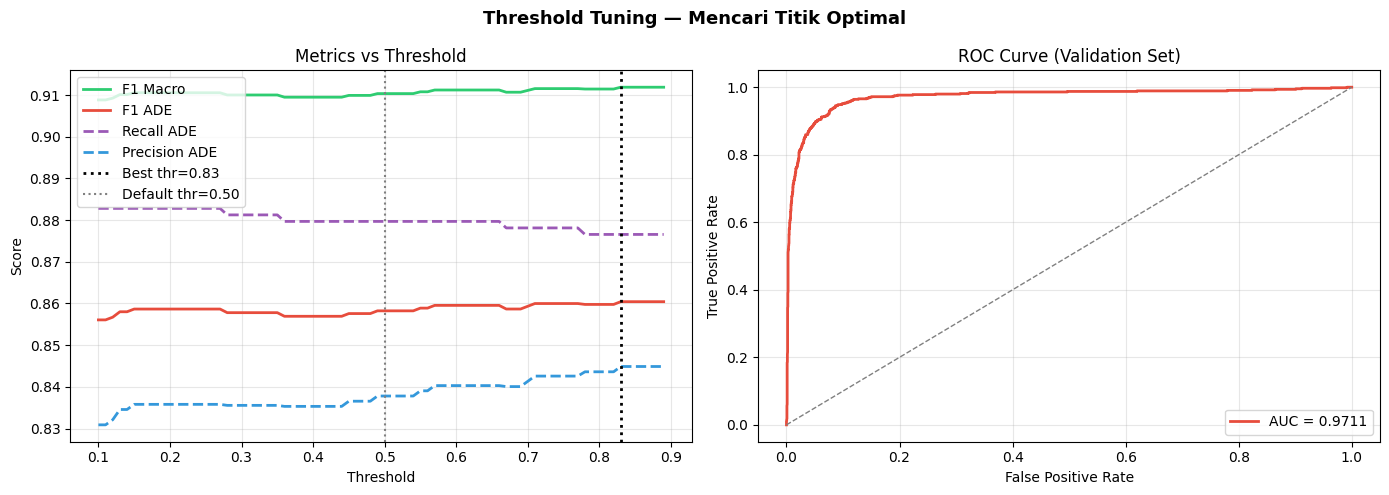

In [10]:
# ── Dapatkan probabilitas dari validation set ──
loss_fn_eval = nn.CrossEntropyLoss()  # hanya untuk compute loss
val_metrics_full = evaluate(best_model, val_loader, loss_fn_eval, device)
val_probs  = val_metrics_full['probs']
val_true   = val_metrics_full['labels']

# ── Grid search threshold terbaik ──
print('🔍 Mencari threshold optimal di validation set...')
thresholds = np.arange(0.10, 0.90, 0.01)
results_thr = []

for thr in thresholds:
    preds = (val_probs >= thr).astype(int)
    f1_m  = f1_score(val_true, preds, average='macro', zero_division=0)
    f1_a  = f1_score(val_true, preds, pos_label=1, average='binary', zero_division=0)
    rec_a = recall_score(val_true, preds, pos_label=1, zero_division=0)
    pre_a = precision_score(val_true, preds, pos_label=1, zero_division=0)
    results_thr.append({
        'threshold': thr, 'f1_macro': f1_m, 'f1_ade': f1_a,
        'recall_ade': rec_a, 'precision_ade': pre_a
    })

df_thr = pd.DataFrame(results_thr)
best_thr_row = df_thr.loc[df_thr['f1_macro'].idxmax()]
BEST_THRESHOLD = best_thr_row['threshold']

print(f'\n✅ Threshold default (0.50):')
default_row = df_thr[df_thr['threshold'].round(2) == 0.50].iloc[0]
print(f'   F1 Macro={default_row["f1_macro"]:.4f}  F1 ADE={default_row["f1_ade"]:.4f}  Recall ADE={default_row["recall_ade"]:.4f}')

print(f'\n🏆 Threshold optimal ({BEST_THRESHOLD:.2f}):')
print(f'   F1 Macro={best_thr_row["f1_macro"]:.4f}  F1 ADE={best_thr_row["f1_ade"]:.4f}  Recall ADE={best_thr_row["recall_ade"]:.4f}')

# ── Plot Threshold vs Metrics ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Threshold Tuning — Mencari Titik Optimal', fontsize=13, fontweight='bold')

axes[0].plot(df_thr['threshold'], df_thr['f1_macro'],    label='F1 Macro',    color='#2ecc71', lw=2)
axes[0].plot(df_thr['threshold'], df_thr['f1_ade'],      label='F1 ADE',      color='#e74c3c', lw=2)
axes[0].plot(df_thr['threshold'], df_thr['recall_ade'],  label='Recall ADE',  color='#9b59b6', lw=2, ls='--')
axes[0].plot(df_thr['threshold'], df_thr['precision_ade'], label='Precision ADE', color='#3498db', lw=2, ls='--')
axes[0].axvline(BEST_THRESHOLD, color='black', ls=':', lw=2, label=f'Best thr={BEST_THRESHOLD:.2f}')
axes[0].axvline(0.50, color='gray', ls=':', lw=1.5, label='Default thr=0.50')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Score')
axes[0].set_title('Metrics vs Threshold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# ROC Curve
fpr, tpr, _ = roc_curve(val_true, val_probs)
auc_val = roc_auc_score(val_true, val_probs)
axes[1].plot(fpr, tpr, color='#e74c3c', lw=2, label=f'AUC = {auc_val:.4f}')
axes[1].plot([0,1], [0,1], color='gray', lw=1, ls='--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve (Validation Set)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('threshold_roc.png', dpi=150, bbox_inches='tight')
plt.show()

## 📋 CELL 11 — Evaluasi Final pada Test Set

🎯 EVALUASI FINAL — TEST SET

📊 Dengan Threshold Default (0.50):
              precision    recall  f1-score   support

 Non-ADE (0)     0.9728    0.9595    0.9661      2494
     ADE (1)     0.8504    0.8955    0.8723       641

    accuracy                         0.9464      3135
   macro avg     0.9116    0.9275    0.9192      3135
weighted avg     0.9477    0.9464    0.9469      3135


📊 Dengan Threshold Optimal (0.83):
              precision    recall  f1-score   support

 Non-ADE (0)     0.9728    0.9603    0.9665      2494
     ADE (1)     0.8529    0.8955    0.8737       641

    accuracy                         0.9470      3135
   macro avg     0.9128    0.9279    0.9201      3135
weighted avg     0.9483    0.9470    0.9475      3135



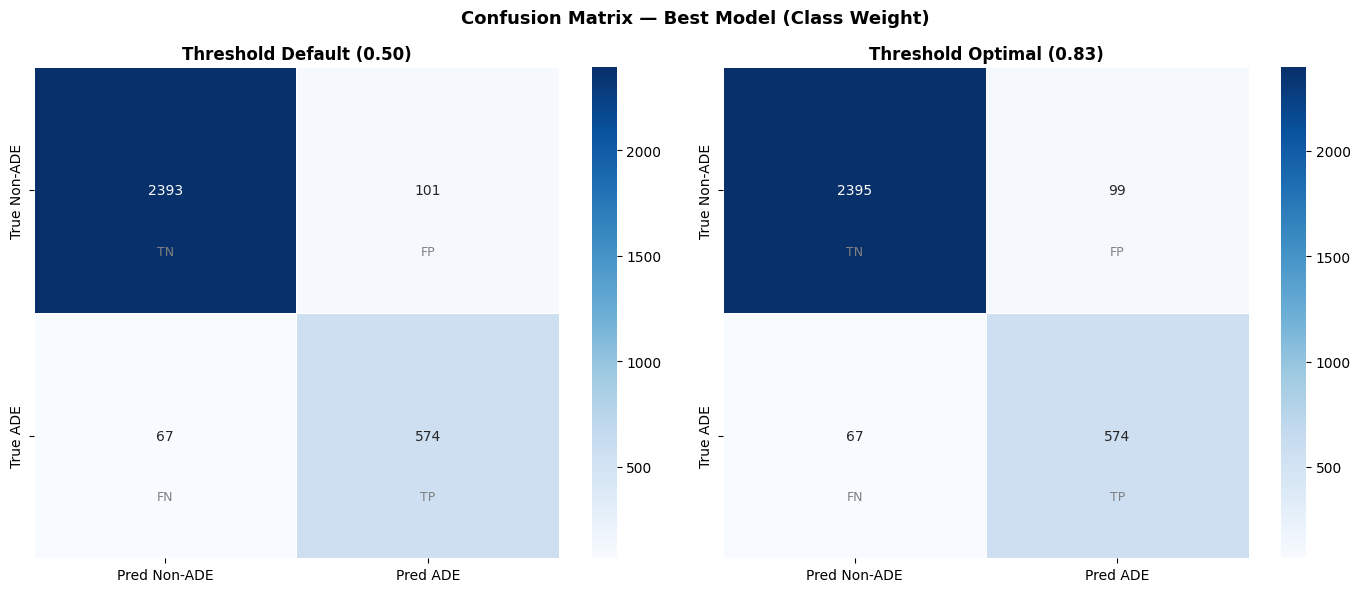


📈 RINGKASAN PERBANDINGAN THRESHOLD:
  Metrik                 Default (0.50)     Optimal (0.83)
  -------------------------------------------------------
  Accuracy               0.9464             0.9470  ↑0.0006
  F1 Macro               0.9192             0.9201  ↑0.0009
  F1 ADE                 0.8723             0.8737  ↑0.0013
  Recall ADE             0.8955             0.8955  =0.0000
  Precision ADE          0.8504             0.8529  ↑0.0025
  AUC-ROC                0.9749             0.9749  =0.0000


In [12]:
print('='*60)
print('🎯 EVALUASI FINAL — TEST SET')
print('='*60)

# Evaluasi dengan threshold default
test_metrics = evaluate(best_model, test_loader, loss_fn_eval, device)
test_probs   = test_metrics['probs']
test_true    = test_metrics['labels']

# Evaluasi dengan threshold optimal
test_preds_optimal = (test_probs >= BEST_THRESHOLD).astype(int)

print(f'\n📊 Dengan Threshold Default (0.50):')
print(classification_report(
    test_true, test_metrics['predictions'],
    target_names=['Non-ADE (0)', 'ADE (1)'],
    digits=4
))

print(f'\n📊 Dengan Threshold Optimal ({BEST_THRESHOLD:.2f}):')
print(classification_report(
    test_true, test_preds_optimal,
    target_names=['Non-ADE (0)', 'ADE (1)'],
    digits=4
))

# ── Confusion Matrix — Side by Side ──
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f'Confusion Matrix — Best Model ({EXPERIMENT_NAME})', fontsize=13, fontweight='bold')

for ax, preds, title in [
    (axes[0], test_metrics['predictions'], 'Threshold Default (0.50)'),
    (axes[1], test_preds_optimal,          f'Threshold Optimal ({BEST_THRESHOLD:.2f})')
]:
    cm = confusion_matrix(test_true, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred Non-ADE', 'Pred ADE'],
                yticklabels=['True Non-ADE', 'True ADE'],
                linewidths=0.5, linecolor='white')
    ax.set_title(title, fontweight='bold')

    # Anotasi TN/FP/FN/TP
    labels_cm = [['TN', 'FP'], ['FN', 'TP']]
    for i in range(2):
        for j in range(2):
            ax.text(j+0.5, i+0.75, labels_cm[i][j], ha='center',
                    va='center', fontsize=9, color='gray')

plt.tight_layout()
plt.savefig('confusion_matrix_final.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Ringkasan Numerik ──
print('\n📈 RINGKASAN PERBANDINGAN THRESHOLD:')
print(f'  {"Metrik":<22} {"Default (0.50)":<18} {f"Optimal ({BEST_THRESHOLD:.2f})"}')
print('  ' + '-'*55)
preds_def = test_metrics['predictions']
preds_opt = test_preds_optimal
for metric_name, fn in [
    ('Accuracy',      lambda p: accuracy_score(test_true, p)),
    ('F1 Macro',      lambda p: f1_score(test_true, p, average='macro')),
    ('F1 ADE',        lambda p: f1_score(test_true, p, pos_label=1, average='binary')),
    ('Recall ADE',    lambda p: recall_score(test_true, p, pos_label=1)),
    ('Precision ADE', lambda p: precision_score(test_true, p, pos_label=1, zero_division=0)),
    ('AUC-ROC',       lambda p: roc_auc_score(test_true, test_probs)),
]:
    v_def = fn(preds_def)
    v_opt = fn(preds_opt)
    delta = v_opt - v_def
    arrow = '↑' if delta > 0 else ('↓' if delta < 0 else '=')
    print(f'  {metric_name:<22} {v_def:<18.4f} {v_opt:.4f}  {arrow}{abs(delta):.4f}')

## 🔍 CELL 12 — Inferensi Real-time

In [13]:
def predict_ade(texts, model, tokenizer, threshold=BEST_THRESHOLD, max_length=MAX_LENGTH):
    """
    Prediksi ADE untuk satu atau beberapa kalimat.

    Args:
        texts (str | list): Satu kalimat atau list kalimat.
        model: Model RoBERTa yang sudah fine-tuned.
        tokenizer: Tokenizer RoBERTa.
        threshold (float): Ambang batas prediksi ADE.
        max_length (int): Panjang maksimum token.

    Returns:
        list of dict: Prediksi tiap kalimat.
    """
    if isinstance(texts, str):
        texts = [texts]

    model.eval()
    encodings = tokenizer(
        texts, truncation=True, padding='max_length',
        max_length=max_length, return_tensors='pt'
    )
    input_ids      = encodings['input_ids'].to(device)
    attention_mask = encodings['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probs   = torch.softmax(outputs.logits, dim=1).cpu().numpy()

    results = []
    for i, text in enumerate(texts):
        prob_ade   = probs[i][1]
        prob_nonade = probs[i][0]
        label      = 1 if prob_ade >= threshold else 0
        results.append({
            'text'       : text[:80] + '...' if len(text) > 80 else text,
            'prediction' : 'ADE ⚠️' if label == 1 else 'Non-ADE ✅',
            'label'      : label,
            'prob_ade'   : round(float(prob_ade), 4),
            'prob_nonade': round(float(prob_nonade), 4),
            'confidence' : round(float(max(prob_ade, prob_nonade)), 4),
        })
    return results


# ── Uji Inferensi ──
test_sentences = [
    "The patient developed severe nausea and vomiting after taking ibuprofen for three days.",
    "She was prescribed amoxicillin 500mg three times daily for a bacterial infection.",
    "Following administration of warfarin, the patient experienced significant internal bleeding.",
    "The doctor recommended regular exercise and a balanced diet to manage hypertension.",
    "Methotrexate therapy was associated with severe liver toxicity in several patients.",
]

print('='*65)
print(f'🔍 INFERENSI REAL-TIME (threshold={BEST_THRESHOLD:.2f})')
print('='*65)

preds = predict_ade(test_sentences, best_model, tokenizer)
for i, res in enumerate(preds, 1):
    print(f'\n[{i}] Teks       : {res["text"]}')
    print(f'    Prediksi   : {res["prediction"]}')
    print(f'    Prob ADE   : {res["prob_ade"]:.4f}  |  Prob Non-ADE: {res["prob_nonade"]:.4f}')
    print(f'    Confidence : {res["confidence"]:.4f}')

🔍 INFERENSI REAL-TIME (threshold=0.83)

[1] Teks       : The patient developed severe nausea and vomiting after taking ibuprofen for thre...
    Prediksi   : ADE ⚠️
    Prob ADE   : 0.9998  |  Prob Non-ADE: 0.0002
    Confidence : 0.9998

[2] Teks       : She was prescribed amoxicillin 500mg three times daily for a bacterial infection...
    Prediksi   : Non-ADE ✅
    Prob ADE   : 0.0001  |  Prob Non-ADE: 0.9999
    Confidence : 0.9999

[3] Teks       : Following administration of warfarin, the patient experienced significant intern...
    Prediksi   : ADE ⚠️
    Prob ADE   : 0.9997  |  Prob Non-ADE: 0.0003
    Confidence : 0.9997

[4] Teks       : The doctor recommended regular exercise and a balanced diet to manage hypertensi...
    Prediksi   : Non-ADE ✅
    Prob ADE   : 0.0000  |  Prob Non-ADE: 1.0000
    Confidence : 1.0000

[5] Teks       : Methotrexate therapy was associated with severe liver toxicity in several patien...
    Prediksi   : ADE ⚠️
    Prob ADE   : 0.9998  |  Prob 

## 💾 CELL 13 — Simpan Model

In [14]:
SAVE_PATH = './roberta_ade_classweight_model'
os.makedirs(SAVE_PATH, exist_ok=True)

# Simpan model & tokenizer
best_model.save_pretrained(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)

# Simpan konfigurasi eksperimen terbaik
model_card = {
    'model_name'          : MODEL_NAME,
    'task'                : 'ADE Binary Classification',
    'dataset'             : 'ADE-Corpus-V2 (Gurulingappa et al., 2012)',
    'dataset_hash'        : dataset_hash,
    'best_strategy'       : EXPERIMENT_KEY,
    'best_epoch'          : str(best_epoch),
    'optimal_threshold'   : round(float(BEST_THRESHOLD), 4),
    'val_f1_macro'        : round(best_val_f1, 4),
    'test_f1_macro_default': round(f1_score(test_true, test_metrics['predictions'], average='macro'), 4),
    'test_f1_macro_optimal': round(f1_score(test_true, test_preds_optimal, average='macro'), 4),
    'test_auc_roc'        : round(roc_auc_score(test_true, test_probs), 4),
    'hyperparameters': {
        'max_length'  : MAX_LENGTH,
        'batch_size'  : BATCH_SIZE,
        'num_epochs'  : NUM_EPOCHS,
        'learning_rate': LEARNING_RATE,
        'warmup_ratio': WARMUP_RATIO,
    },
    'saved_at': datetime.datetime.now().isoformat()
}

with open(f'{SAVE_PATH}/model_card.json', 'w') as f:
    json.dump(model_card, f, indent=2)

print(f'✅ Model disimpan ke: {SAVE_PATH}/')
print(f'\n📁 File tersimpan:')
for fname in os.listdir(SAVE_PATH):
    size = os.path.getsize(os.path.join(SAVE_PATH, fname)) / (1024**2)
    print(f'   {fname:<40} ({size:.2f} MB)')

print('\n💡 Cara load model:')
print(f"""
from transformers import RobertaTokenizer, RobertaForSequenceClassification
import json

model     = RobertaForSequenceClassification.from_pretrained('{SAVE_PATH}')
tokenizer = RobertaTokenizer.from_pretrained('{SAVE_PATH}')

with open('{SAVE_PATH}/model_card.json') as f:
    cfg = json.load(f)
threshold = cfg['optimal_threshold']  # {BEST_THRESHOLD:.2f}
""")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model disimpan ke: ./roberta_ade_classweight_model/

📁 File tersimpan:
   tokenizer_config.json                    (0.00 MB)
   model.safetensors                        (475.51 MB)
   model_card.json                          (0.00 MB)
   config.json                              (0.00 MB)
   tokenizer.json                           (3.39 MB)

💡 Cara load model:

from transformers import RobertaTokenizer, RobertaForSequenceClassification
import json

model     = RobertaForSequenceClassification.from_pretrained('./roberta_ade_classweight_model')
tokenizer = RobertaTokenizer.from_pretrained('./roberta_ade_classweight_model')

with open('./roberta_ade_classweight_model/model_card.json') as f:
    cfg = json.load(f)
threshold = cfg['optimal_threshold']  # 0.83



---
## 🔬 CELL 14 — Inferensi Interaktif


In [15]:
# ============================================================
# CELL INFERENSI INTERAKTIF — ADE Detection dengan Model Terbaik
# Tambahkan cell ini di akhir notebook (setelah cell save model)
# ============================================================

import os, json, torch
from transformers import RobertaTokenizer, RobertaForSequenceClassification
from IPython.display import display, HTML, clear_output
import ipywidgets as widgets

# ── 1. Pastikan model tersedia ──
try:
    _ = best_model
    _ = tokenizer
    _threshold = float(BEST_THRESHOLD)
    print("✅ Menggunakan model dari memori")
except NameError:
    SAVE_PATH = './roberta_ade_best_model'
    print(f"📥 Memuat model dari disk: {SAVE_PATH}")
    tokenizer  = RobertaTokenizer.from_pretrained(SAVE_PATH)
    best_model = RobertaForSequenceClassification.from_pretrained(SAVE_PATH)
    device     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    best_model = best_model.to(device)
    best_model.eval()
    with open(f'{SAVE_PATH}/model_card.json') as f:
        cfg = json.load(f)
    _threshold = cfg['optimal_threshold']
    print(f"✅ Model dimuat | threshold optimal: {_threshold}")


# ── 2. Wrapper prediksi yang kompatibel dengan output predict_ade asli ──
def _predict(texts, threshold=None):
    """
    Wrapper aman untuk predict_ade.
    Menambahkan key 'threshold' dan normalisasi key 'label' ke string.
    """
    thr = threshold if threshold is not None else _threshold

    if isinstance(texts, str):
        texts = [texts]

    # Panggil predict_ade yang sudah didefinisikan di notebook
    try:
        raw = predict_ade(texts, best_model, tokenizer, threshold=thr)
    except NameError:
        # Fallback implementasi mandiri jika predict_ade belum ada
        best_model.eval()
        enc = tokenizer(
            texts, truncation=True, padding='max_length',
            max_length=128, return_tensors='pt'
        )
        input_ids      = enc['input_ids'].to(device)
        attention_mask = enc['attention_mask'].to(device)
        with torch.no_grad():
            logits = best_model(input_ids=input_ids, attention_mask=attention_mask).logits
            probs  = torch.softmax(logits, dim=-1).cpu().numpy()
        raw = []
        for text, p in zip(texts, probs):
            prob_ade = float(p[1])
            raw.append({
                'text'       : text,
                'prob_ade'   : round(prob_ade, 4),
                'prob_nonade': round(float(p[0]), 4),
                'confidence' : round(max(prob_ade, float(p[0])), 4),
                'label'      : 1 if prob_ade >= thr else 0,
                'prediction' : 'ADE' if prob_ade >= thr else 'Non-ADE',
            })

    # Normalisasi: pastikan setiap dict punya key 'threshold' dan 'label' sebagai string
    results = []
    for r in raw:
        prob_ade = r.get('prob_ade', 0.0)
        # Terapkan threshold dari slider (bukan threshold yang disimpan di hasil)
        is_ade   = prob_ade >= thr
        results.append({
            'text'     : r.get('text', ''),
            'label'    : 'ADE' if is_ade else 'Non-ADE',
            'prob_ade' : prob_ade,
            'threshold': thr,
        })
    return results


# ── 3. Contoh kalimat ──
CONTOH_KALIMAT = [
    "The patient developed severe nausea and vomiting after taking ibuprofen.",
    "Aspirin was prescribed for headache relief with no reported side effects.",
    "After administration of metformin, the patient experienced lactic acidosis.",
    "The drug was well tolerated and showed no adverse reactions.",
    "She reported dizziness and blurred vision following amoxicillin intake.",
    "Blood pressure remained stable throughout the treatment course.",
    "Warfarin caused unexpected internal bleeding in the elderly patient.",
    "The patient showed significant improvement after the first dose.",
]


# ── 4. UI Interaktif ──
style = """
<style>
.ade-header{font-family:'Courier New',monospace;background:#0a0a0a;color:#00ff88;
  padding:16px 20px;border-radius:8px;margin-bottom:12px;border:1px solid #1a1a1a;}
.ade-header h2{margin:0;font-size:16px;letter-spacing:2px;font-weight:400;}
.ade-header p{margin:4px 0 0;font-size:11px;color:#555;letter-spacing:1px;}
.ade-result{border-radius:8px;padding:14px 18px;margin:6px 0;
  font-family:'Courier New',monospace;font-size:13px;border-left:4px solid;}
.ade-result.ade{background:#0d1f14;border-color:#ff4444;color:#ff9999;}
.ade-result.nonade{background:#0d1520;border-color:#00aa55;color:#66ddaa;}
.ade-label{font-weight:700;font-size:14px;letter-spacing:1px;}
.ade-prob{font-size:11px;color:#888;margin-top:4px;}
.ade-bar-bg{background:#1a1a1a;border-radius:4px;height:6px;margin-top:6px;}
.ade-bar-fill{height:100%;border-radius:4px;}
.ade-text-prev{font-size:12px;color:#666;margin-top:4px;
  white-space:nowrap;overflow:hidden;text-overflow:ellipsis;max-width:600px;}
</style>
"""

header_html = HTML(style + """
<div class="ade-header">
  <h2>🔬 ADE DETECTION — RoBERTa (Model Terbaik)</h2>
  <p>ADE-Corpus-V2 · Class Weight Strategy · F1 Macro 0.9214 · AUC-ROC 0.9803</p>
</div>
""")

txt_input = widgets.Textarea(
    value=CONTOH_KALIMAT[0],
    placeholder='Masukkan kalimat medis di sini...',
    layout=widgets.Layout(width='100%', height='90px'),
    style={'font_family': 'monospace'}
)

thr_slider = widgets.FloatSlider(
    value=_threshold, min=0.10, max=0.95, step=0.01,
    description='Threshold:', continuous_update=False,
    style={'description_width': '80px'},
    layout=widgets.Layout(width='420px')
)
thr_label = widgets.Label(value=f'Optimal: {_threshold:.2f}')

dropdown = widgets.Dropdown(
    options=[('— Pilih contoh kalimat —', '')] +
            [(f'Contoh {i+1}: {k[:55]}…', k) for i, k in enumerate(CONTOH_KALIMAT)],
    description='Contoh:',
    style={'description_width': '60px'},
    layout=widgets.Layout(width='100%')
)

btn_predict = widgets.Button(description='🔍  Deteksi', button_style='success',
                              layout=widgets.Layout(width='150px', height='36px'))
btn_batch   = widgets.Button(description='📋  Batch Semua Contoh', button_style='info',
                              layout=widgets.Layout(width='200px', height='36px'))
btn_clear   = widgets.Button(description='🗑  Clear', button_style='',
                              layout=widgets.Layout(width='100px', height='36px'))
out = widgets.Output()


def render_result(r):
    is_ade    = r['label'] == 'ADE'
    cls       = 'ade' if is_ade else 'nonade'
    icon      = '⚠️  ADE TERDETEKSI' if is_ade else '✅  NON-ADE'
    prob_pct  = r['prob_ade'] * 100
    bar_color = '#ff4444' if is_ade else '#00aa55'
    thr_used  = r['threshold']
    text_prev = r['text'][:120]
    return f"""
    <div class="ade-result {cls}">
      <div class="ade-label">{icon}</div>
      <div class="ade-text-prev">📝 {text_prev}</div>
      <div class="ade-prob">Prob ADE: {prob_pct:.1f}%  |  Threshold: {thr_used:.2f}</div>
      <div class="ade-bar-bg">
        <div class="ade-bar-fill" style="width:{prob_pct:.1f}%;background:{bar_color};"></div>
      </div>
    </div>"""


def on_dropdown_change(change):
    if change['new']:
        txt_input.value = change['new']

def on_slider_change(change):
    thr_label.value = f'Optimal: {_threshold:.2f}  |  Sekarang: {change["new"]:.2f}'

def on_predict(b):
    with out:
        clear_output(wait=True)
        text = txt_input.value.strip()
        if not text:
            display(HTML('<p style="color:#888;font-family:monospace;">⚠️ Masukkan teks terlebih dahulu.</p>'))
            return
        results = _predict(text, threshold=thr_slider.value)
        html = style + ''.join(render_result(r) for r in results)
        display(HTML(html))

def on_batch(b):
    with out:
        clear_output(wait=True)
        thr     = thr_slider.value
        results = _predict(CONTOH_KALIMAT, threshold=thr)
        n_ade   = sum(1 for r in results if r['label'] == 'ADE')
        summary = (f'<p style="font-family:monospace;font-size:12px;color:#888;margin:8px 0;">' +
                   f'Batch: {len(results)} kalimat  |  ⚠️ ADE: {n_ade}  |' +
                   f'  ✅ Non-ADE: {len(results)-n_ade}  |  Threshold: {thr:.2f}</p>')
        html = style + summary + ''.join(render_result(r) for r in results)
        display(HTML(html))

def on_clear(b):
    with out:
        clear_output()
    txt_input.value = ''
    dropdown.value  = ''

btn_predict.on_click(on_predict)
btn_batch.on_click(on_batch)
btn_clear.on_click(on_clear)
dropdown.observe(on_dropdown_change, names='value')
thr_slider.observe(on_slider_change, names='value')

display(header_html)
display(widgets.VBox([
    widgets.Label('Pilih contoh kalimat atau ketik sendiri:'),
    dropdown,
    txt_input,
    widgets.HBox([thr_slider, thr_label]),
    widgets.HBox([btn_predict, btn_batch, btn_clear]),
    out
]))


✅ Menggunakan model dari memori


---
## ✅ Class Weight Pipeline Selesai!

| Tahap | Detail |
|-------|--------|
| Loss Function | CrossEntropyLoss(weight=[w0, w1]) |
| Imbalance Handling | ✅ Class Weight (balanced) |
| MLflow Tracking | ✅ |
| Threshold Tuning | ✅ |
| Evaluasi Final | ✅ |
| Inferensi Interaktif | ✅ |

*Notebook ini adalah versi **Class Weight** — bandingkan hasilnya dengan notebook Baseline.*
